## Functions and Imports

In [13]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import re

# Add sibling folder to sys.path (for notebooks)
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', 'y_utils')))

import functions  # now import your module
import config

import sys
sys.stdout.flush()

In [14]:


def plot_dose_response_from_betas(regression_beta_fp, title="Dose-Response Function: Temperature on Suicide", poly_max=4):
    """
    Reads distributed lag regression betas, extracts polynomial terms,
    computes total effect, and plots a dose-response curve with gradient color.

    Parameters:
    -----------
    regression_beta_fp : str
        File path to CSV with regression output. Must contain columns 'term' and 'beta'.
    title : str
        Title for the plot.
    poly_max : int
        Maximum polynomial degree to include (default is 4).
    """
    # Load betas
    regression_betas = pd.read_csv(regression_beta_fp)

    # Extract polynomial degree and lag from term names like "tavg_poly3_l2"
    def extract_poly_and_lag(term):
        m = re.match(r"tavg_poly(\d)_l(\d+)", term)
        return (int(m.group(1)), int(m.group(2))) if m else (None, None)

    regression_betas['poly'], regression_betas['lag'] = zip(*regression_betas['term'].map(extract_poly_and_lag))
    regression_betas = regression_betas.dropna(subset=['poly', 'lag'])

    # Sum betas across lags for each polynomial degree
    sum_betas = regression_betas.groupby('poly')['beta'].sum().sort_index()
    betas = [sum_betas.get(i, 0) for i in range(1, poly_max + 1)]

    # Define dose-response curve
    def dose_response_curve(x, coefs):
        return sum(coef * (x ** i) for i, coef in enumerate(coefs, start=1))

    # Generate curve
    x_vals = np.linspace(-5, 30, 500)
    y_vals = dose_response_curve(x_vals, betas)

    # Create a gradient line
    points = np.array([x_vals, y_vals]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    norm = plt.Normalize(x_vals.min(), x_vals.max())
    lc = LineCollection(segments, cmap='coolwarm', norm=norm)
    lc.set_array(x_vals)
    lc.set_linewidth(2)

    # Plot
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.add_collection(lc)
    ax.set_xlim(x_vals.min(), x_vals.max())
    ax.set_ylim(y_vals.min() - 0.1 * abs(y_vals.min()), y_vals.max() + 0.1 * abs(y_vals.max()))
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)

    # Labels
    fig.suptitle(title, fontsize=14)
    ax.set_xlabel("Temperature (°C)")
    ax.set_ylabel("Estimated Effect on Suicide Rate")

    # Colorbar
    cbar = fig.colorbar(lc, ax=ax)
    cbar.set_label("Temperature (°C)")

    # Caption
    plt.figtext(0.5, 0.01,
                "Effect computed as sum of lagged polynomial betas from distributed lag regression.",
                ha='center', va='bottom', fontsize=9)

    plt.grid(True)
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.show()


## Plotting

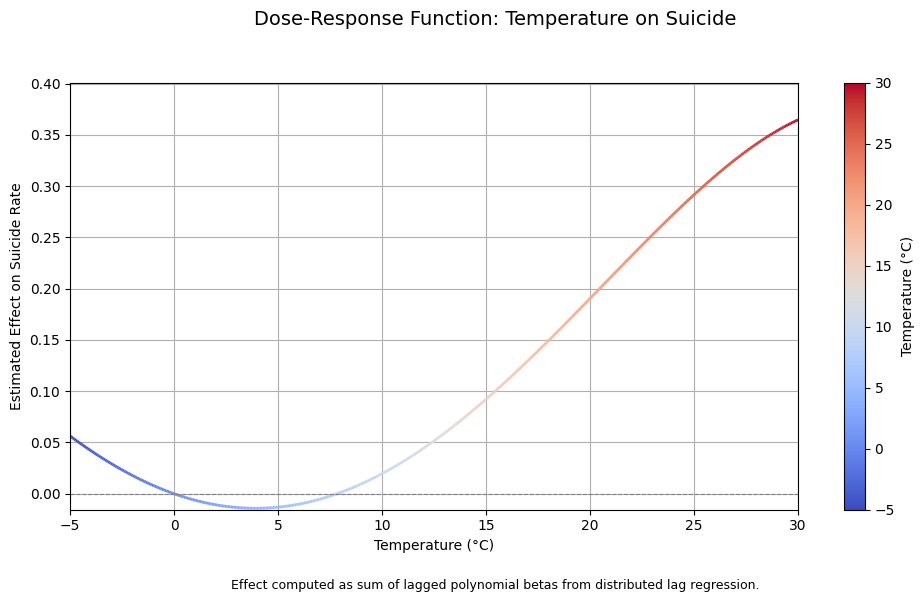

In [15]:
plot_dose_response_from_betas(config.REGRESSION_BETA_FP)

[1/6] Loading shapefile...
[2/6] Loading county-level data...
[3/6] Validating column names...
[4/6] Filtering and averaging data...
No time range provided, averaging over entire dataset period...
[5/6] Merging county data with shapefile...
[6/6] Plotting map...
Done.


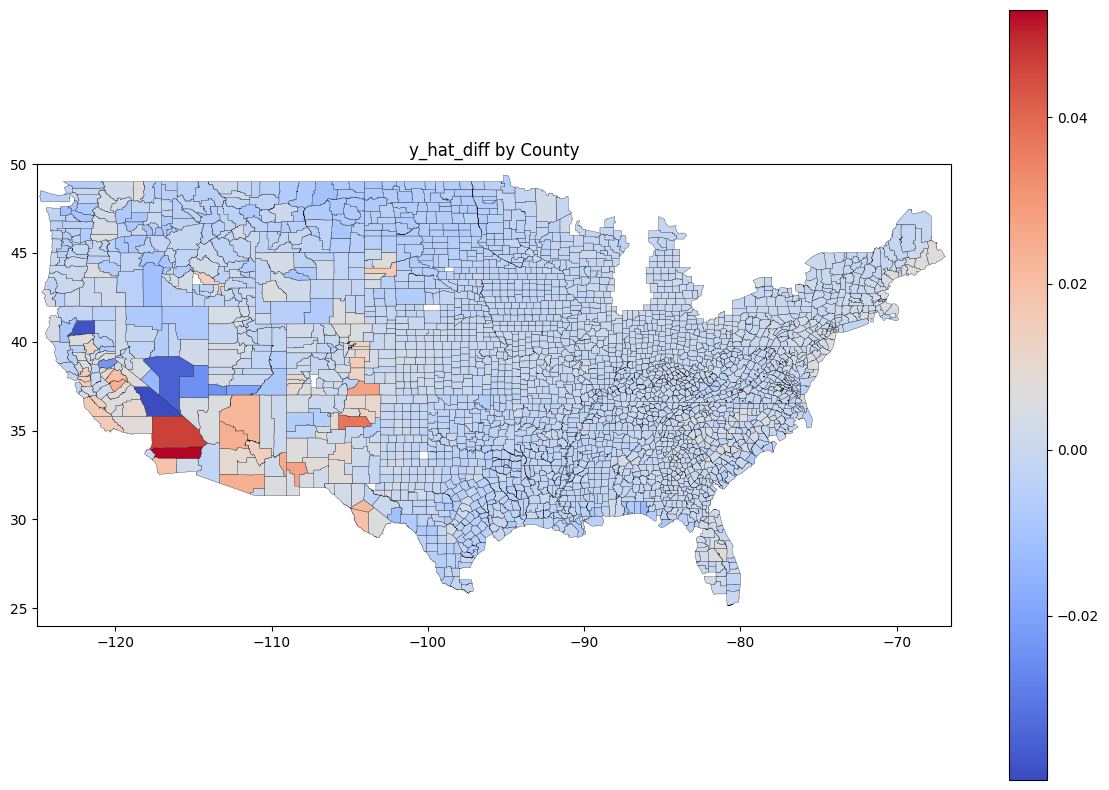

In [2]:
functions.plot_county_data(
    shapefile_path=config.USA_COUNTY_SHAPEFILE_FP,
    shapefile_id_col="GEOID",
    county_data_path=config.ATTRIBUTION_V2_FP,
    county_id_col="adm2_id",
    value_col="y_hat_diff",
    crop_bounds=[-125, -66.5, 24, 50],  # Mainland US
    start_time = 2000,
    end_time = 2004
)


[1/6] Loading shapefile...


[2/6] Loading county-level data...
[3/6] Validating column names...
[4/6] Filtering and averaging data...
No time range provided, averaging over entire dataset period...
[5/6] Merging county data with shapefile...
[6/6] Plotting map...
Done.


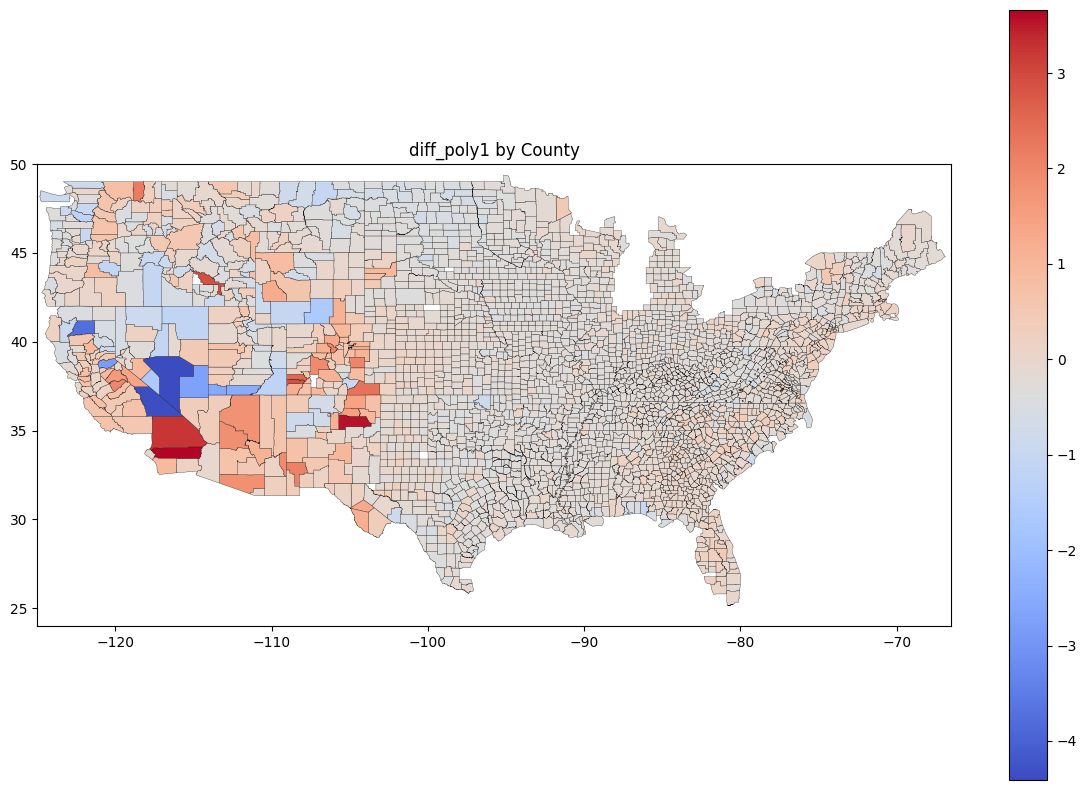

In [3]:
functions.plot_county_data(
    shapefile_path=config.USA_COUNTY_SHAPEFILE_FP,
    shapefile_id_col="GEOID",
    county_data_path=config.ATTRIBUTION_V2_FP,
    county_id_col="adm2_id",
    value_col="diff_poly1",
    start_time=2000,
    end_time=2004,
    crop_bounds=[-125, -66.5, 24, 50]  # Mainland US
)


In [9]:
import pandas as pd

def filter_and_avg(df, county_id_col, value_col, time_col=None, start_time=None, end_time=None):
    """
    Filter dataframe by time range (if provided) and return average of value_col grouped by county_id_col.

    Parameters:
    - df: pandas DataFrame
    - county_id_col: column name for county ID in df
    - value_col: column name for the value to average
    - time_col: optional column name for time (str or datetime)
    - start_time: optional filter start time (string or numeric)
    - end_time: optional filter end time (string or numeric)

    Returns:
    - grouped average DataFrame or None if filtering results in no data
    """

    import pandas as pd

    if time_col and start_time is not None and end_time is not None:
        print(f"Filtering data between {start_time} and {end_time} on column '{time_col}'...")
        try:
            df[time_col] = pd.to_datetime(df[time_col], errors='coerce')
            start = pd.to_datetime(start_time)
            end = pd.to_datetime(end_time)
        except Exception:
            try:
                df[time_col] = pd.to_numeric(df[time_col], errors='coerce')
                start = float(start_time)
                end = float(end_time)
            except Exception as e:
                print(f"❌ Error parsing time columns or values: {e}")
                return None
        df_filtered = df[(df[time_col] >= start) & (df[time_col] <= end)]
        if df_filtered.empty:
            print("❌ No data found in specified time range after filtering.")
            return None
        df_avg = df.groupby(county_id_col)[value_col].mean().reset_index()
        df_avg.rename(columns={value_col: value_col}, inplace=True)
        return df_avg
    else:
        print("No time range provided, averaging over entire dataset period...")
        df_avg = df.groupby(county_id_col)[value_col].mean().reset_index()
        df_avg.rename(columns={value_col: value_col}, inplace=True)
        return df_avg

In [2]:

def plot_county_diff(
    shapefile_path,
    shapefile_id_col,
    
    # For dataset 1
    county_data_path_1=None,
    county_id_col_1=None,
    value_col1=None,
    separate_files_by_year_1=False,
    yearly_raw_folder_1=None,
    yearly_raw_template_1=None,
    
    # For dataset 2
    county_data_path_2=None,
    county_id_col_2=None,
    value_col2=None,
    separate_files_by_year_2=False,
    yearly_raw_folder_2=None,
    yearly_raw_template_2=None,
    
    years = None,

    vmin=None,
    vmax=None,
    crop_bounds=None,
    time_col = None,
):

    import geopandas as gpd
    import pandas as pd
    import matplotlib.pyplot as plt
    import sys
    import os

    print("[1/8] Loading shapefile...")
    sys.stdout.flush()
    try:
        gdf = gpd.read_file(shapefile_path)
    except Exception as e:
        print(f"❌ ERROR loading shapefile: {e}")
        return

    print("[2/8] Loading first county-level dataset...")
    
    if separate_files_by_year_1:
        if not (yearly_raw_folder_1 and yearly_raw_template_1 and years):
            print("❌ Must provide yearly_raw_folder_1, yearly_raw_template_1, and years when separate_files_by_year_1=True")
            return
        df_list_1 = []
        for yr in years:
            path_1 = os.path.join(yearly_raw_folder_1, yearly_raw_template_1.format(year=yr))
            print(f"  Loading first dataset file for year {yr}: {path_1}")
            try:
                df_year_1 = pd.read_csv(path_1)
                df_year_1['year'] = yr
                df_list_1.append(df_year_1)
            except FileNotFoundError:
                print(f"❌ First dataset file not found for year {yr}: {path_1}. Skipping this year.")
            except pd.errors.EmptyDataError:
                print(f"❌ First dataset file for year {yr} is empty: {path_1}. Skipping this year.")
            except Exception as e:
                print(f"❌ Error loading first dataset file for year {yr}: {e}. Skipping this year.")
        if not df_list_1:
            print("❌ No data loaded for any year in first dataset, aborting.")
            return
        try:
            df_1 = pd.concat(df_list_1, ignore_index=True)
        except Exception as e:
            print(f"❌ Error concatenating first dataset yearly dataframes: {e}")
            return
    else:
        try:
            df_1 = pd.read_csv(county_data_path_1)
        except Exception as e:
            print(f"❌ Error loading first county-level data: {e}")
            return

    print("[3/8] Loading second county-level dataset...")
    if separate_files_by_year_2:
        if not (yearly_raw_folder_2 and yearly_raw_template_2 and years):
            print("❌ Must provide yearly_raw_folder_2, yearly_raw_template_2, and years when separate_files_by_year_2=True")
            return
        df_list_2 = []
        for yr in years:
            path_2 = os.path.join(yearly_raw_folder_2, yearly_raw_template_2.format(year=yr))
            print(f"  Loading second dataset file for year {yr}: {path_2}")
            try:
                df_year_2 = pd.read_csv(path_2)
                df_year_2['year'] = yr
                df_list_2.append(df_year_2)
            except FileNotFoundError:
                print(f"❌ Second dataset file not found for year {yr}: {path_2}. Skipping this year.")
            except pd.errors.EmptyDataError:
                print(f"❌ Second dataset file for year {yr} is empty: {path_2}. Skipping this year.")
            except Exception as e:
                print(f"❌ Error loading second dataset file for year {yr}: {e}. Skipping this year.")
        if not df_list_2:
            print("❌ No data loaded for any year in second dataset, aborting.")
            return
        try:
            df_2 = pd.concat(df_list_2, ignore_index=True)
        except Exception as e:
            print(f"❌ Error concatenating second dataset yearly dataframes: {e}")
            return
    else:
        try:
            df_2 = pd.read_csv(county_data_path_2)
        except Exception as e:
            print(f"❌ Error loading second county-level data: {e}")
            return


    print("[4/8] Validating column names...")
    shapefile_cols = gdf.columns.tolist()
    df1_cols = df_1.columns.tolist()
    df2_cols = df_2.columns.tolist()

    missing = False
    if shapefile_id_col not in shapefile_cols:
        print(f"❌ '{shapefile_id_col}' not found in shapefile columns.")
        print("Available shapefile columns:", shapefile_cols)
        missing = True
    if county_id_col_1 not in df1_cols:
        print(f"❌ '{county_id_col_1}' not found in first county data columns.")
        print("Available columns:", df1_cols)
        missing = True
    if value_col1 not in df1_cols:
        print(f"❌ '{value_col1}' not found in first county data columns.")
        print("Available columns:", df1_cols)
        missing = True
    if county_id_col_2 not in df2_cols:
        print(f"❌ '{county_id_col_2}' not found in second county data columns.")
        print("Available columns:", df2_cols)
        missing = True
    if value_col2 not in df2_cols:
        print(f"❌ '{value_col2}' not found in second county data columns.")
        print("Available columns:", df2_cols)
        missing = True
    if time_col and (time_col not in df1_cols or time_col not in df2_cols):
        print(f"❌ '{time_col}' not found in both county data columns.")
        print("First data columns:", df1_cols)
        print("Second data columns:", df2_cols)
        missing = True

    if missing:
        return

    start_time = years[0]  # will be 2000
    end_time = years[-1] 

    print("[5/8] Processing first dataset...")
    df1_avg = filter_and_avg(df_1, county_id_col_1, value_col1, time_col, start_time, end_time)
    if df1_avg is None:
        return

    print("[6/8] Processing second dataset...")
    df2_avg = filter_and_avg(df_2, county_id_col_2, value_col2, time_col, start_time, end_time)
    if df2_avg is None:
        return

    print("[7/8] Calculating difference and merging with shapefile...")

    df1_avg_renamed = df1_avg.rename(columns={value_col1: 'value_1', county_id_col_1: 'county_id'})
    df2_avg_renamed = df2_avg.rename(columns={value_col2: 'value_2', county_id_col_2: 'county_id'})

    df1_avg_renamed['county_id'] = df1_avg_renamed['county_id'].astype(int)
    df2_avg_renamed['county_id'] = df2_avg_renamed['county_id'].astype(int)

    # Merge on county_id
    merged_df = pd.merge(df1_avg_renamed, df2_avg_renamed, on='county_id', how='outer')

    # Compute difference column safely (fill missing values if needed)
    merged_df['diff'] = merged_df['value_1'] - merged_df['value_2']

    # Now merge with GeoDataFrame
    gdf[shapefile_id_col] = gdf[shapefile_id_col].astype(int)
    merged_df['county_id'] = merged_df['county_id'].astype(int)

    gdf_merged = gdf.merge(merged_df[['county_id', 'diff']], left_on=shapefile_id_col, right_on='county_id', how='left')


    print("[8/8] Plotting difference map...")
    fig, ax = plt.subplots(figsize=(12, 8))
    gdf_merged.plot(
        column='diff',
        cmap="coolwarm",
        linewidth=0.2,
        edgecolor="black",
        legend=True,
        vmin=vmin,
        vmax=vmax,
        ax=ax
    )
    ax.set_title(f"Difference: {value_col1} - {value_col2} by County")
    if crop_bounds:
        ax.set_xlim(crop_bounds[0], crop_bounds[1])
        ax.set_ylim(crop_bounds[2], crop_bounds[3])

    print("Done.")
    plt.tight_layout()
    plt.show()

[1/8] Loading shapefile...
[2/8] Loading first county-level dataset...
  Loading first dataset file for year 1979: /global/scratch/users/yougsanghvi/aggregated_results_era5_usa/era5_usa_agg_1979.csv
  Loading first dataset file for year 1980: /global/scratch/users/yougsanghvi/aggregated_results_era5_usa/era5_usa_agg_1980.csv
  Loading first dataset file for year 1981: /global/scratch/users/yougsanghvi/aggregated_results_era5_usa/era5_usa_agg_1981.csv
[3/8] Loading second county-level dataset...
  Loading second dataset file for year 1979: /global/scratch/users/yougsanghvi/aggregated_results_gdnat_usa/gdnat_usa_agg_1979.csv
  Loading second dataset file for year 1980: /global/scratch/users/yougsanghvi/aggregated_results_gdnat_usa/gdnat_usa_agg_1980.csv
  Loading second dataset file for year 1981: /global/scratch/users/yougsanghvi/aggregated_results_gdnat_usa/gdnat_usa_agg_1981.csv
[4/8] Validating column names...
[5/8] Processing first dataset...
Filtering data between 1979 and 1981 on 

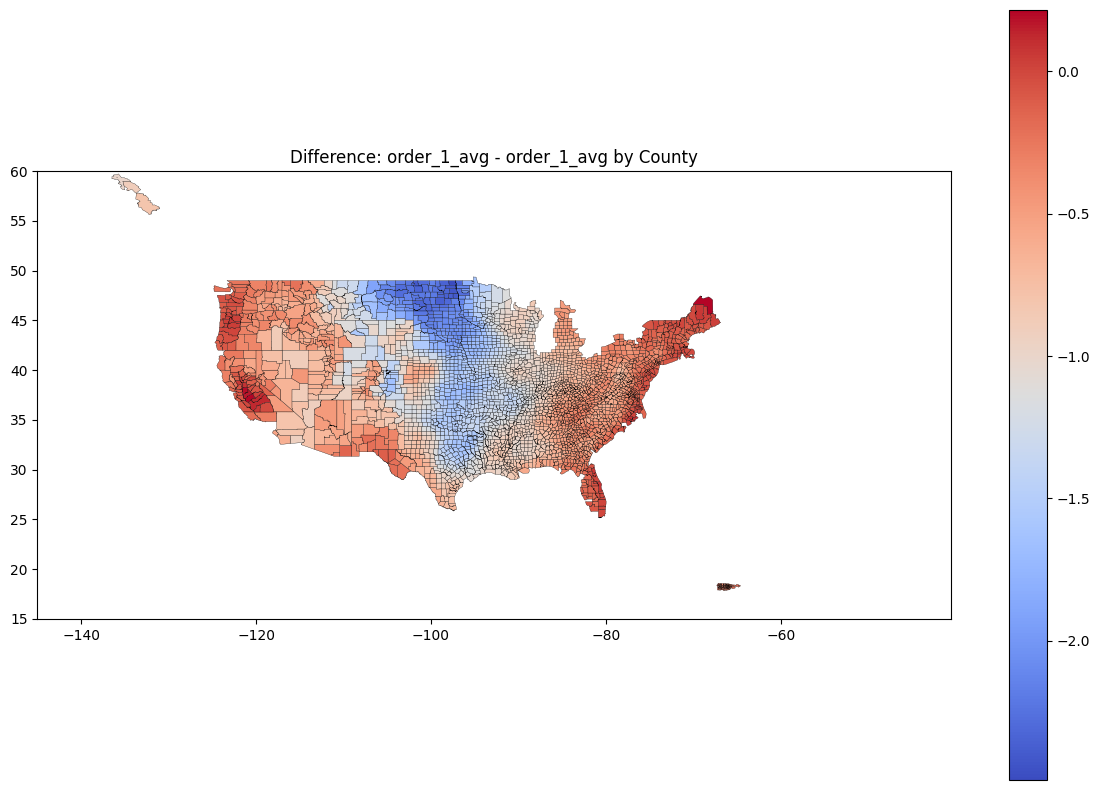

In [12]:
plot_county_diff(
    shapefile_path=config.USA_COUNTY_SHAPEFILE_FP,
    shapefile_id_col="GEOID",

    county_id_col_1="poly_id",
    value_col1="order_1_avg",
    separate_files_by_year_1=True,
    yearly_raw_folder_1=config.ERA5_AGG_FOLDER,
    yearly_raw_template_1=config.ERA5_AGG_FILE_FORMAT,

    county_data_path_2=None,
    county_id_col_2="poly_id",
    value_col2="order_1_avg",
    separate_files_by_year_2=True,
    yearly_raw_folder_2=config.GDNAT_FOLDER_PATH,
    yearly_raw_template_2=config.GDNAT_FILE_FORMAT,

    years=range(1979, 1982),  # Adjust as needed
    time_col="year",
    crop_bounds=[-145, -40.5, 15, 60]
)
